## 1. Image Enhancement in Spatial Domain


### 1.1 Gray Level Transformations


### 1.1.1 Image Negative


Image negative is a point processing transformation that reverses the intensity levels of an image meaning dark pixels become bright and bright pixels become dark, producing a reversed-tone version (like a photo film negative).

For an 8-bit grayscale image:

$$
s = (L-1)-r
$$

Where, <br>
$\qquad L =$ Number of gray levels (256 for 8-bit) <br>
$\qquad r =$ Input pixel intensity <br>
$\qquad s =$ Output pixel intensity <br>


**Program to implement image negative**


In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [14]:
img = cv2.imread("images/img-1.png", 1)

if img is None:
    print("Image not found!")
    exit()

In [16]:
negative = cv2.bitwise_not(img)

In [ ]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
negative_rgb = cv2.cvtColor(negative, cv2.COLOR_BGR2RGB)

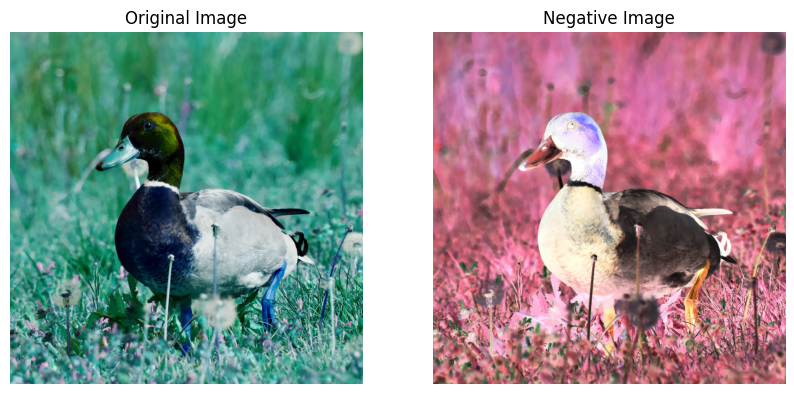

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Negative Image")
plt.imshow(negative_rgb,)
plt.axis("off")

plt.show()

### 1.1.2 Log Transformation


Log transformation is a gray-level transformation technique that maps a narrow range of low-intensity (dark) pixel values to a wider range of output values, thereby enhancing the details in darker regions of an image.

$$
s = c \cdot \text{log}(1+r)
$$

Where, <br>
$\qquad r =$ Input pixel intensity <br>
$\qquad s =$ Output pixel intensity <br>
$\qquad c =$ Scaling constant, defined as: <br>

$$
c = \frac{255}{\text{log}(1+r_{max})}
$$

$\qquad r_{max} =$ maximum pixel value in the input image (usually 255)


**Program to implement log transformation**


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [8]:
img = cv2.imread("images/img-1.png", 0)

if img is None:
    print("Image not found!")
    exit()

In [9]:
img_float = np.float32(img)

log_transformed = np.log1p(img_float)

log_transformed = cv2.normalize(log_transformed, None, 0, 255, cv2.NORM_MINMAX)

log_transformed = np.uint8(log_transformed)

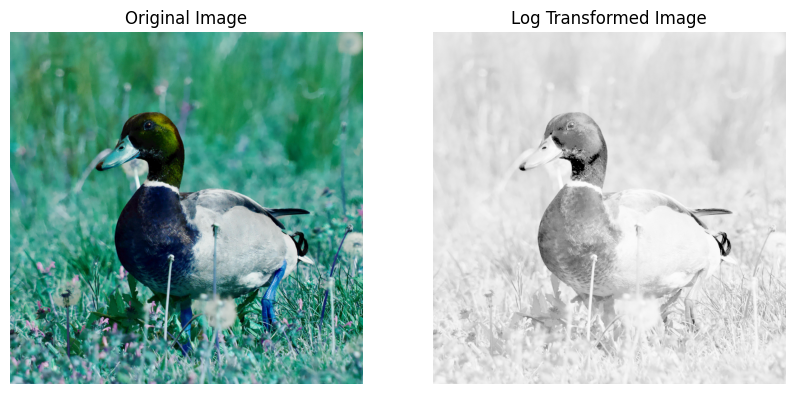

In [12]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Log Transformed Image")
plt.imshow(log_transformed, cmap="gray")
plt.axis("off")

plt.show()

# **Thresholding**

Thresholding is a simple yet powerful segmentation technique that converts a grayscale image into a binary image (black and white) by comparing each pixel's intensity to a fixed value called the threshold value ($T$). Mathematically, it is defined as,

$$
s = \begin{cases} 255 & \text{if } r \geq T \\ 0 & \text{if } r < T \end{cases}
$$

Where, <br>
$\qquad r =$ Input pixel intensity <br>
$\qquad s =$ Output pixel intensity <br>
$\qquad T =$ Threshold value <br>


In [18]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 60, 255, cv2.THRESH_BINARY)

cv2.imshow("Threshold", thresh)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [19]:
ret, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

cv2.imshow("Automatic", otsu)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [20]:
adaptive = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
)

cv2.imshow("Adaptive", adaptive)

cv2.waitKey(0)
cv2.destroyAllWindows()